In [44]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, TimeSeriesSplit, GridSearchCV, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, LinearRegression, Lasso, Ridge
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, mean_squared_error, r2_score, mean_absolute_error
DIR = os.path.join(os.getcwd(), "data")

In [38]:
data = {}
for filename in os.listdir(DIR):
    if filename.endswith("_csv_CLEAN.csv"):
        filepath = os.path.join(DIR, f"{filename}")
        response = pd.read_csv(filepath, index_col="Date", parse_dates=True)
        data[filename] = response

        
FEATURE_COLS = [
    'rsi_14', "return_1day", "return_5day", "return_10day", "return_20day", "sma_5", "sma_10", 
    "close_ratio_amv_10", "sma_20", "close_ratio_amv_20", 
    "close_ratio_amv_5", 'macd_line', 'bb_width', 'bb_pct_b', 
    'volatility_10_day', 'volatility_20_day', 
    'volume_1day', 'volume_20_sma', 'volume_normalize_ratio',
]

# for stock, dataframe in data.items():
    # print(stock)
    # print(dataframe.head(5))


#VFV Example
vfv_df = data["VFV_TO_csv_CLEAN.csv"]
vfv_df = vfv_df.dropna(subset=["future_return"])
X = vfv_df[FEATURE_COLS]
y_logistical_reg = vfv_df["target"]
y_linear_reg = vfv_df["future_return"]

#Creating the train and test
X_train, X_test, y_train_log, y_test_log, y_train_lin, y_test_lin = train_test_split(
    X, 
    y_logistical_reg, 
    y_linear_reg, 
    test_size=0.2, 
    shuffle=False 
)


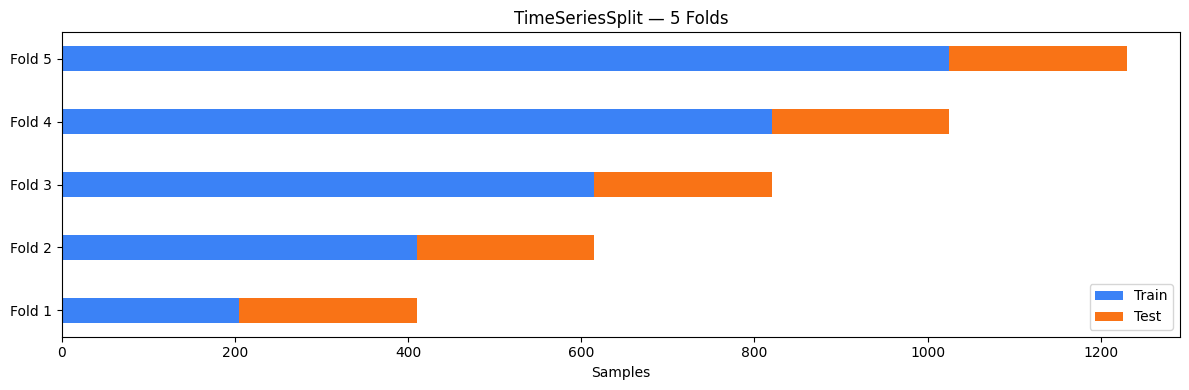

In [ ]:
#Time Series Cross Validation
time_series_cross_validation = TimeSeriesSplit(n_splits=5)

# Visualize the folds
figure, axis = plt.subplots(figsize=(12, 4))
for fold_i, (train_idx, test_idx) in enumerate(time_series_cross_validation.split(X)):
    axis.barh(fold_i, len(train_idx), left=0, height=0.4, color="#3b82f6", label="Train" if fold_i == 0 else "")
    axis.barh(fold_i, len(test_idx), left=len(train_idx), height=0.4, color="#f97316", label="Test" if fold_i == 0 else "")
axis.set_yticks(range(5))
axis.set_yticklabels([f"Fold {i+1}" for i in range(5)])
axis.set_xlabel("Samples")
axis.set_title("TimeSeriesSplit — 5 Folds")
axis.legend()
plt.tight_layout()
plt.show()

In [53]:

preprocessor = ColumnTransformer(
    transformers=[
        ("num_cleaner", StandardScaler(), FEATURE_COLS)
    ]
)
param_grid = {'alpha': [0.001, 0.01, 0.1, 1.0, 10.0, 100.0, 1000.0]}
#Pipeline for Direction (1 or 0)
log_pipeline = Pipeline([
    ("cleaning_steps", preprocessor),
    ("logistic_model", LogisticRegression())
])
#Pipeline for Predicated Values 
lin_pipeline = Pipeline([
    ("cleaning_steps", preprocessor),
    ("linear_model", LinearRegression())
])
#Pipeline for Direction + L1 (Lasso)
log_l1_pipeline = Pipeline([
    ("cleaning_steps", preprocessor),
    ("logistic_model", LogisticRegression(l1_ratio=1, solver="saga", max_iter=2000))
])
#Pipeline for Direction + L2 (Ridge)
log_l2_pipeline = Pipeline([
    ("cleaning_steps", preprocessor),
    ("logistic_model", LogisticRegression(l1_ratio=0, max_iter=2000))
])

# print("Training Logistic Model")
# log_pipeline.fit(X_train, y_train_log)

# print("Training Linear Model")
# lin_pipeline.fit(X_train, y_train_lin)


In [ ]:


#Accuracy for target
# log_predictions = log_pipeline.predict(X_test)
# log_accuracy = accuracy_score(y_test_log, log_predictions)
# print("\n--- Logistic Regression Results ---")
# print(f"Accuracy: {log_accuracy * 100:.2f}%")

# #Accuracy for future_return
# lin_predictions = lin_pipeline.predict(X_test)
# lin_mse = mean_squared_error(y_test_lin, lin_predictions)
# lin_r2 = r2_score(y_test_lin, lin_predictions)
# print("\n--- Linear Regression Results ---")
# print(f"Mean Squared Error: {lin_mse:.6f}")
# print(f"R-Squared (R2): {lin_r2:.4f}")


--- Logistic Regression Results ---
Accuracy: 60.98%

--- Linear Regression Results ---
Mean Squared Error: 0.001014 (Lower is better)
R-Squared (R2): -0.9640 (1.0 is perfect)


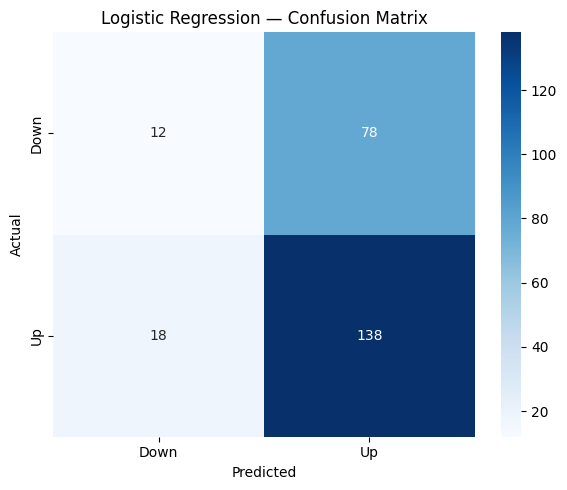

In [ ]:
# Confusion matrix
# cm = confusion_matrix(y_test_log, log_predictions)
# fig, ax = plt.subplots(figsize=(6, 5))
# sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
#             xticklabels=["Down", "Up"], yticklabels=["Down", "Up"])
# ax.set_xlabel("Predicted")
# ax.set_ylabel("Actual")
# ax.set_title("Logistic Regression — Confusion Matrix")
# plt.tight_layout()
# plt.show()

In [54]:
#Implementing TimeSeriesSplit
models = {
    "Logistic (baseline)": log_pipeline,
    "Logistic + L1 (Lasso)": log_l1_pipeline,
    "Logistic + L2 (Ridge)": log_l2_pipeline,
}
cv_results = {}
for name, pipe in models.items():
    scores = cross_val_score(pipe, X, y_logistical_reg, cv=time_series_cross_validation, scoring="accuracy")
    cv_results[name] = scores
    print(f"{name:30s}  Accuracy: {scores.mean():.4f} ± {scores.std():.4f}  (folds: {np.round(scores, 4)})")

Logistic (baseline)             Accuracy: 0.4956 ± 0.0842  (folds: [0.5366 0.4927 0.3366 0.5317 0.5805])
Logistic + L1 (Lasso)           Accuracy: 0.4927 ± 0.0912  (folds: [0.522  0.478  0.3317 0.522  0.6098])
Logistic + L2 (Ridge)           Accuracy: 0.4956 ± 0.0842  (folds: [0.5366 0.4927 0.3366 0.5317 0.5805])


ValueError: Invalid parameter 'alpha' for estimator Pipeline(steps=[('cleaning_steps',
                 ColumnTransformer(transformers=[('num_cleaner',
                                                  StandardScaler(),
                                                  ['rsi_14', 'return_1day',
                                                   'return_5day',
                                                   'return_10day',
                                                   'return_20day', 'sma_5',
                                                   'sma_10',
                                                   'close_ratio_amv_10',
                                                   'sma_20',
                                                   'close_ratio_amv_20',
                                                   'close_ratio_amv_5',
                                                   'macd_line', 'bb_width',
                                                   'bb_pct_b',
                